In [1520]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1521]:
df=pd.read_csv('flipkart_all_brand.csv')

In [1522]:
raw_df=df.copy()

In [1523]:
df.head(5)

,url,item_id,variant_id,title,description,product_category,category_tree,brand,image_url,price,...,reviews,additional_image_urls,timestamp,input_url,input_all_variations,error,error_code,warning,warning_code,discovery_input
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026-06-17T19:09:06.657Z,https://www.flipkart.com/haier-7-kg-5-star-powered-ai-dbt-inverter-motor-inbuilt-heater-525-mm-super-drum-washer-fully-automatic-front-load-washing-machine-in-built-heater-grey-black/p/itm10e2f857ee981?pid=WMNHG6PPWAYV2UEX,True,Parse error: Cannot read properties of undefined (reading 'image'),parse_error,NaN,NaN,"{""url"":""https://www.flipkart.com/washing-machines/pr?sid=j9e,abm,8qx"",""all_variations"":true}"
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026-06-17T19:09:19.149Z,https://www.flipkart.com/haier-7-kg-anti-bacterial-vortex-pulsator-1300-rpm-spray-function-wash-programs-magic-filter-rat-mesh-semi-automatic-top-load-washing-machine-maroon-white/p/itm9190f81967149?pid=WMNGZ77MKX89B7TF,True,Parse error: Cannot read properties of undefined (reading 'image'),parse_error,NaN,NaN,"{""url"":""https://www.flipkart.com/washing-machines/pr?sid=j9e,abm,8qx"",""all_variations"":true}"
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026-06-17T19:09:56.029Z,https://www.flipkart.com/whirlpool-6-5-kg-magic-clean-5-star-fully-automatic-top-load-washing-machine-grey/p/itm4da0f8467315d?pid=WMNGNZFCKG3J2GMB,True,Parse error: Cannot read properties of undefined (reading 'image'),parse_error,NaN,NaN,"{""url"":""https://www.flipkart.com/washing-machines/pr?sid=j9e,abm,8qx"",""all_variations"":true}"
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2026-06-17T19:10:05.564Z,https://www.flipkart.com/haier-8-kg-oceanus-wave-drum-15-min-quick-wash-fully-automatic-top-load-washing-machine-brown-grey/p/itm44234313622df?pid=WMNHBW8BAZHXCZHQ,True,Parse error: Cannot read properties of undefined (reading 'image'),parse_error,NaN,NaN,"{""url"":""https://www.flipkart.com/washing-machines/pr?sid=j9e,abm,8qx"",""all_variations"":true}"
4,https://www.flipkart.com/lg-9-kg-fully-automatic-top-load-washing-machine-in-built-heater-black/p/itme6c2900e17754?pid=WMNHMVUNUHJBHVJU,WMNHMVUNUHJBHVJU,WMNHMVUNUHJBHVJU,LG 9 kg Fully Automatic Top Load Washing Machine with In-built Heater Black,Buy LG 9 kg Fully Automatic Top Load Washing Machine with In-built Heater Black for Rs.33990.0 online. LG 9 kg Fully Automatic Top Load Washing Machine with In-built Heater Black at best prices with FREE shipping & cash on delivery. Only Genuine Products. 30 Day Replacement Guarantee.,Home & Kitchen > Home Appliances > Washing Machines > LG Washing Machines,"[{""name"":""Home & Kitchen"",""url"":""https://www.flipkart.com/home-kitchen/pr?sid=j9e&marketplace=FLIPKART""},{""name"":""Home Appliances"",""url"":""https://www.flipkart.com/home-kitchen/home-appliances/pr?sid=j9e,abm&marketplace=FLIPKART""},{""name"":""Washing Machines"",""url"":""https://www.flipkart.com/washing-machines/pr?sid=j9e,abm,8qx&marketplace=FLIPKART""},{""name"":""LG Washing Machines"",""url"":""https://www.flipkart.com/washing-machines/lg~brand/pr?sid=j9e,abm,8qx&marketplace=FLIPKART""}]",LG,https://rukmini1.flixcart.com/image/1500/1500/xif0q/washing-machine-new/q/g/o/-original-imahzyyxerz73bnw.jpeg?q=70,"₹33,990.00",...,"[{""review_id"":""fbe9139b-1ddc-4883-8e20-7af032282889"",""title"":""Wonderful"",""content"":""Excellent product, I purchased through online Flipkart warranty card not signed by any authorised person.\nMy question is if any problems arise in the future what to do ?"",""min_rating"":1,""max_rating"":5,""rating"":4},{""review_id"":""7d7ba88d-d25b-4306-866c-14b1d55e329f"",""title"":""Fabulous!"",""content"":""Good product"",""min_rating"":1,""max_rating"":5,""rating"":5},{""review_id"":""8526bfe7-af1f-4070-ab68-f08bdda67f05"",""title"":""Must buy!"",""content"":""Machine works fantastic with below pros and cons.\nPutting this review after using it for 15 days\n\n\nPros:\n

In [1524]:
df.duplicated().sum()

np.int64(0)

In [1525]:
df=df.drop(index=[0,1,2,3],axis=0)

In [1526]:
df.columns

Index(['url', 'item_id', 'variant_id', 'title', 'description',
       'product_category', 'category_tree', 'brand', 'image_url', 'price',
       'sale_price', 'availability', 'availability_date', 'group_id',
       'listing_has_variations', 'variant_attributes', 'variants',
       'store_name', 'seller_url', 'seller_privacy_policy', 'seller_tos',
       'return_policy', 'return_window', 'target_countries', 'store_country',
       'category_urls', 'star_rating', 'review_count', 'reviews',
       'additional_image_urls', 'timestamp', 'input_url',
       'input_all_variations', 'error', 'error_code', 'warning',
       'warning_code', 'discovery_input'],
      dtype='object')

In [1527]:
df=df.drop(['url' ,'variant_attributes','description','image_url','variant_id','category_tree','store_name','seller_url', 'seller_privacy_policy', 'seller_tos',
        'target_countries', 'store_country',
       'category_urls','return_policy','reviews',
       'additional_image_urls', 'timestamp', 'input_url',
       'input_all_variations', 'error', 'error_code', 'warning',
       'warning_code', 'discovery_input'],axis=1
)

In [1528]:
df.duplicated().sum()

np.int64(169)

In [1529]:
df=df.drop_duplicates()

In [1530]:
df.duplicated().sum()

np.int64(0)

In [1531]:
df.shape

(393, 14)

In [1532]:
def extract_capacity_kg(text):
    match =re.search(r'(\d+(?:\.\d+)?)\s*kg', str(text).lower(), re.IGNORECASE)
    return float(match.group(1)) if match else np.nan
def extract_colors(text):
     colors=['Black', 'Grey', 'Silver', 'White', 'Blue',
    'Red', 'Maroon', 'Yellow', 'Purple', 'Brown',
    'Inox', 'Navy','Multicolor']
     matches = []
     for color in colors:
        if re.search(rf'\b{re.escape(color)}\b', str(text), re.IGNORECASE):
            matches.append(color)
     return ', '.join(matches) if matches else np.nan
def extract_rating(text):
     rating= re.search(r'(\d)\s*star', str(text).lower(),re.IGNORECASE)
     return int(rating.group(1)) if rating else np.nan
def extract_automation(text):
     text =str(text).lower()
     if 'fully automatic' in text: return 'Fully Automatic'
     elif 'semi automatic' in text: return 'Semi Automatic'
     elif 'manual' in text: return 'Manual'
     else: return np.nan

def extract_load_type(text):
     text =str(text).lower()
     if 'top load' in text: return 'Top Load'
     elif 'front load' in text: return 'Front Load'
     else: return np.nan
def extract_steam(text):
    return text.str.contains(r'steam|hygiene steam|power steam|puristeam', case =False,regex=True)
def extract_heater(text):
    return text.str.contains(r'heater|in-built heater|inbuilt heater', case=False,regex=True)
def extract_inverter(text):
    return text.str.contains(r'inverter', case=False,regex=True)
def extract_wifi(text):
    return text.str.contains(r'wifi|wi-fi', case=False,regex=True)
def extract_ai(text):
    return text.str.contains(r'AI|AI  Tech|AI Enabled|AI Ecobubble| AI Smart',case =False, regex=True)
def extract_category(text):
    parts = str(text).split('>')
    parts = [p.strip() for p in parts if p.strip()] # Clean and remove empty parts
    if len(parts) > 1:
        category = parts[1]
        return category if category else 'Home Appliances'
    elif len(parts) > 0:
        category = parts[0]
        return category if category != 'nan' else 'Home Appliances'
    else:
        return 'Home Appliances'
def extract_product(text):
    parts = str(text).split('>')
    parts = [p.strip() for p in parts if p.strip()] # Clean and remove empty parts
    if len(parts) > 1:
        product = parts[2]
        return product if product else 'Washing Machines'
    elif len(parts) > 0:
        product = parts[0]
        return product if product != 'nan' else 'Washing Machines'
    else:
        return 'Washing Machines'
# def extract_final_price(text)
#    text = re.search('\d+',str(text), re.IGNORECASE)




In [1533]:
df['avg_rating']=df['star_rating'].apply(lambda x: x if x else np.nan)
df['capacity_kg']=df['title'].apply(extract_capacity_kg)
df['colors']=df['title'].apply(extract_colors)
df['energy_star_ratings']=df['title'].apply(extract_rating)
df['automation']=df['title'].apply(extract_automation)
df['load_type']=df['title'].apply(extract_load_type)
df['steam']=extract_steam(df['title'])
df['heater']=extract_heater(df['title'])
df['wifi']=extract_wifi(df['title'])
df['ai']=extract_ai(df['title'])
df['inverter']=extract_inverter(df['title'])
df['category']=df['product_category'].apply(extract_category)
df['product']=df['product_category'].apply(extract_product)
df=df[df['sale_price'].notna()]
df['return_window']= df['return_window'].fillna(0).astype(int)
df['review_count']=df['review_count'].fillna(0).astype(int)
df['availability_date']=pd.to_datetime(df['availability_date'])
df['platform']='Flipkart'

In [1534]:
def extract_final_price(text):
   text = str(text).replace('₹','').replace(',','')
   return float(text)
df['initial_price'] =df['price'].apply(extract_final_price).astype(int)

def extract_list_price(text):
   text = str(text).replace('₹','').replace(',','')
   k = re.search(r'(\d+\.?\d*)',text,re.IGNORECASE)
   return float(k.group(0)) if k else None
df['final_price'] = df['sale_price'].apply(extract_list_price).fillna(0).astype(int)

In [1535]:
df['discount_pct'] = (((df['initial_price']-df['final_price'])*100)/df['initial_price']).astype(int)

In [1536]:
df=df.drop(['price','sale_price','variants','product_category','group_id'], axis =1)

In [1537]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [1538]:
df['product'].value_counts()

,count
product,
Washing Machines,380


In [1539]:
print(df['automation'].value_counts())
print(df['colors'].value_counts())
print(df['avg_rating'].value_counts())
print(df['load_type'].value_counts())
print(df['steam'].value_counts())
print(df['heater'].value_counts())
print(df['wifi'].value_counts())
print(df['ai'].value_counts())
print(df['inverter'].value_counts())

automation
Fully Automatic    231
Semi Automatic     147
Name: count, dtype: int64
colors
Grey                   118
Black, Grey             54
Black                   53
White                   30
Silver                  21
White, Maroon           14
Grey, White             13
White, Blue             11
Blue                    10
Black, White             9
Multicolor               8
Grey, Brown              6
Red                      6
Black, Silver            4
White, Red               3
Maroon                   3
Black, Brown             2
Black, Blue              2
Grey, Red                2
Black, Grey, Yellow      1
Grey, Purple             1
Black, Red               1
Red, Maroon              1
Grey, Blue               1
Brown                    1
White, Purple            1
Grey, White, Blue        1
Black, Maroon            1
Name: count, dtype: int64
avg_rating
4.3    126
4.2     68
4.4     57
4.1     40
4.0     36
4.5     16
3.9     10
4.7      2
3.8      2
3.0      1
2.6    

In [1540]:
df.head(10)

,item_id,title,brand,availability,availability_date,listing_has_variations,return_window,star_rating,review_count,avg_rating,...,heater,wifi,ai,inverter,category,product,platform,initial_price,final_price,discount_pct
4,WMNHMVUNUHJBHVJU,LG 9 kg Fully Automatic Top Load Washing Machine with In-built Heater Black,LG,in_stock,2026-06-17,True,10,4.4,6351,4.4,...,True,False,False,False,Home Appliances,Washing Machines,Flipkart,33990,23990,29
5,WMNH9KYU7GHMTGZ2,"Haier 8 kg With Ultra Fresh Air Technology, Oceanus Wave Steel Drum, Balance Clean Pulsator, Custom Wash Cycles with 15 Mins Quick Wash, Magic Filter Fully Automatic Top Load Washing Machine Grey, Black",Haier,in_stock,2026-06-17,True,10,4.3,8621,4.3,...,False,False,True,False,Home Appliances,Washing Machines,Flipkart,27000,16680,38
6,WMNHDAGKEB4AG3UJ,Haier 10.5 kg Fully Automatic Top Load Washing Machine with In-built Heater Silver,Haier,in_stock,2026-06-17,True,10,4.3,8621,4.3,...,True,False,True,False,Home Appliances,Washing Machines,Flipkart,37490,24590,34
7,WMNGGUWZK6VEQPXD,"Samsung 7 kg 5 Star, Ecobubble, Soft Closing Door, Digital Inverter Fully Automatic Top Load Washing Machine Grey",Samsung,in_stock,2026-06-17,True,10,4.3,5245,4.3,...,False,False,False,True,Home Appliances,Washing Machines,Flipkart,22500,18690,16
8,WMNGGUWZED7JAXZZ,"Samsung 8 kg 5 star, Ecobubble, Soft Closing Door, Digital Inverter Fully Automatic Top Load Washing Machine Grey",Samsung,in_stock,2026-06-17,True,10,4.2,2474,4.2,...,False,False,False,True,Home Appliances,Washing Machines,Flipkart,27000,18848,30
9,WMNHAP2XXXHRXHZQ,"Samsung 10 kg 5 Star, AI Wash, AI Energy Mode, Wi-Fi, Ecobubble, AI VRT+, Soft Closing Door, Digital Inverter Fully Automatic Top Load Washing Machine Grey",Samsung,in_stock,2026-06-17,True,10,4.3,5245,4.3,...,False,True,True,True,Home Appliances,Washing Machines,Flipkart,33990,25990,23
10,WMNH76QPY4CAYR6U,"LG 7 kg 5 Star, Smart Inverter Technology, TurboDrum, Smart Diagnosis with Soft Closing Door Fully Automatic Top Load Washing Machine Black",LG,in_stock,2026-06-17,True,10,4.4,6351,4.4,...,False,False,False,True,Home Appliances,Washing Machines,Flipkart,27490,19990,27
11,WMNGBFX49DZJWFKZ,"realme TechLife 7 kg 5 Star rating Semi Automatic Top Load Washing Machine White, Black",realme TechLife,in_stock,2026-06-17,True,10,4.2,9005,4.2,...,False,False,False,False,Home Appliances,Washing Machines,Flipkart,12490,7790,37
12,WMNHF89XSVFADPPK,"VW 7.5 kg Semi Automatic Top Load Washing Machine Black, Grey",VW,in_stock,2026-06-17,True,10,4.4,387,4.4,...,False,False,False,False,Home Appliances,Washing Machines,Flipkart,18999,7490,60
13,WMNHG6PPWAYV2UEX,"Haier 7 kg 5 Star with Powered by AI-DBT, Inverter Motor, Inbuilt Heater, 525 mm Super Drum, Washer Fully Automatic Front Load Washing Machine with In-built Heater Grey, Black",Haier,in_stock,2026-06-17,True,10,4.3,324,4.3,...,True,False,True,True,Home Appliances,Washing Machines,Flipkart,42000,26890,35


In [1541]:
popular_brands = brand_counts[brand_counts > 15].index
print(popular_brands)
df_cleaned = df[df['brand'].isin(popular_brands)]
df_cleaned.head()

Index(['Voltas Beko', 'Haier', 'IFB', 'Samsung', 'Whirlpool', 'LG', 'Godrej',
       'realme TechLife', 'BOSCH', 'Thomson'],
      dtype='object', name='brand')


,item_id,title,brand,availability,availability_date,listing_has_variations,return_window,star_rating,review_count,avg_rating,...,heater,wifi,ai,inverter,category,product,platform,initial_price,final_price,discount_pct
4,WMNHMVUNUHJBHVJU,LG 9 kg Fully Automatic Top Load Washing Machine with In-built Heater Black,LG,in_stock,2026-06-17,True,10,4.4,6351,4.4,...,True,False,False,False,Home Appliances,Washing Machines,Flipkart,33990,23990,29
5,WMNH9KYU7GHMTGZ2,"Haier 8 kg With Ultra Fresh Air Technology, Oceanus Wave Steel Drum, Balance Clean Pulsator, Custom Wash Cycles with 15 Mins Quick Wash, Magic Filter Fully Automatic Top Load Washing Machine Grey, Black",Haier,in_stock,2026-06-17,True,10,4.3,8621,4.3,...,False,False,True,False,Home Appliances,Washing Machines,Flipkart,27000,16680,38
6,WMNHDAGKEB4AG3UJ,Haier 10.5 kg Fully Automatic Top Load Washing Machine with In-built Heater Silver,Haier,in_stock,2026-06-17,True,10,4.3,8621,4.3,...,True,False,True,False,Home Appliances,Washing Machines,Flipkart,37490,24590,34
7,WMNGGUWZK6VEQPXD,"Samsung 7 kg 5 Star, Ecobubble, Soft Closing Door, Digital Inverter Fully Automatic Top Load Washing Machine Grey",Samsung,in_stock,2026-06-17,True,10,4.3,5245,4.3,...,False,False,False,True,Home Appliances,Washing Machines,Flipkart,22500,18690,16
8,WMNGGUWZED7JAXZZ,"Samsung 8 kg 5 star, Ecobubble, Soft Closing Door, Digital Inverter Fully Automatic Top Load Washing Machine Grey",Samsung,in_stock,2026-06-17,True,10,4.2,2474,4.2,...,False,False,False,True,Home Appliances,Washing Machines,Flipkart,27000,18848,30


In [1542]:
df_cleaned.to_csv('filtered_data.csv', index=False)

#**EXPLORATORY DATA ANALYSIS**

In [1543]:
df_cleaned.describe()

,availability_date,return_window,star_rating,review_count,avg_rating,capacity_kg,energy_star_ratings,initial_price,final_price,discount_pct
count,274,309.0,297.000000,309.000000,297.000000,309.000000,131.0,309.000000,309.000000,309.000000
mean,2026-06-17 00:00:00,10.0,4.242088,1753.919094,4.242088,8.461165,5.0,32891.404531,22587.647249,29.045307
min,2026-06-17 00:00:00,10.0,2.600000,0.000000,2.600000,5.500000,5.0,10499.000000,7790.000000,2.000000
25%,2026-06-17 00:00:00,10.0,4.200000,132.000000,4.200000,7.000000,5.0,19696.000000,13960.000000,20.000000
50%,2026-06-17 00:00:00,10.0,4.300000,542.000000,4.300000,8.000000,5.0,27690.000000,18690.000000,27.000000
75%,2026-06-17 00:00:00,10.0,4.300000,2474.000000,4.300000,9.000000,5.0,43200.000000,27999.000000,39.000000
max,2026-06-17 00:00:00,10.0,5.000000,9005.000000,5.000000,14.000000,5.0,275000.000000,176990.000000,57.000000
std,NaN,0.0,0.205037,2391.890650,0.205037,1.738631,0.0,20849.442792,13931.916345,12.665190


In [1544]:
print(df_cleaned['load_type'].value_counts())
print(df_cleaned['automation'].value_counts())
print(df_cleaned['final_price'].describe())
print(df_cleaned['avg_rating'].describe())
print(df_cleaned['capacity_kg'].value_counts().sort_index())

load_type
Top Load      214
Front Load     93
Name: count, dtype: int64
automation
Fully Automatic    196
Semi Automatic     112
Name: count, dtype: int64
count       309.000000
mean      22587.647249
std       13931.916345
min        7790.000000
25%       13960.000000
50%       18690.000000
75%       27999.000000
max      176990.000000
Name: final_price, dtype: float64
count    297.000000
mean       4.242088
std        0.205037
min        2.600000
25%        4.200000
50%        4.300000
75%        4.300000
max        5.000000
Name: avg_rating, dtype: float64
capacity_kg
5.5      3
6.0      5
6.5     20
7.0     66
7.5     20
8.0     71
8.5     20
9.0     29
9.5      5
10.0    27
10.5     4
11.0    14
11.5     3
12.0    14
13.0     1
14.0     7
Name: count, dtype: int64


In [1545]:
realme=df_cleaned[df_cleaned['brand']=='BOSCH']
realme.describe()

,availability_date,return_window,star_rating,review_count,avg_rating,capacity_kg,energy_star_ratings,initial_price,final_price,discount_pct
count,17,18.0,17.000000,18.000000,17.000000,18.000000,1.0,18.000000,18.000000,18.000000
mean,2026-06-17 00:00:00,10.0,4.235294,688.611111,4.235294,7.944444,5.0,48752.166667,31818.055556,33.333333
min,2026-06-17 00:00:00,10.0,2.600000,0.000000,2.600000,6.500000,5.0,23100.000000,15400.000000,18.000000
25%,2026-06-17 00:00:00,10.0,4.300000,58.000000,4.300000,7.000000,5.0,46765.000000,28340.000000,28.500000
50%,2026-06-17 00:00:00,10.0,4.300000,1096.000000,4.300000,8.000000,5.0,51240.000000,34589.500000,33.500000
75%,2026-06-17 00:00:00,10.0,4.300000,1096.000000,4.300000,8.750000,5.0,55615.000000,37190.000000,39.000000
max,2026-06-17 00:00:00,10.0,4.700000,1096.000000,4.700000,11.000000,5.0,77990.000000,43999.000000,43.000000
std,NaN,0.0,0.434369,527.447364,0.434369,1.247219,NaN,13680.673823,7897.189310,6.902685


In [1546]:
realme=df_cleaned[df_cleaned['brand']=='realme TechLife']
realme.describe()

,availability_date,return_window,star_rating,review_count,avg_rating,capacity_kg,energy_star_ratings,initial_price,final_price,discount_pct
count,18,19.0,19.000000,19.000000,19.000000,19.000000,6.0,19.000000,19.000000,19.000000
mean,2026-06-17 00:00:00,10.0,4.147368,4474.368421,4.147368,8.657895,5.0,25832.105263,13200.526316,46.947368
min,2026-06-17 00:00:00,10.0,4.000000,129.000000,4.000000,7.000000,5.0,12490.000000,7790.000000,37.000000
25%,2026-06-17 00:00:00,10.0,4.100000,302.000000,4.100000,7.500000,5.0,17490.000000,9790.000000,44.500000
50%,2026-06-17 00:00:00,10.0,4.200000,1852.000000,4.200000,8.500000,5.0,21990.000000,11490.000000,47.000000
75%,2026-06-17 00:00:00,10.0,4.200000,9005.000000,4.200000,10.000000,5.0,28990.000000,13790.000000,50.000000
max,2026-06-17 00:00:00,10.0,4.200000,9005.000000,4.200000,12.000000,5.0,59490.000000,27990.000000,53.000000
std,NaN,0.0,0.069669,4431.189234,0.069669,1.518887,0.0,13648.415284,6035.072929,4.339402


In [1547]:
df_cleaned= df_cleaned[df_cleaned['initial_price']<100000]
df_cleaned.describe()

,availability_date,return_window,star_rating,review_count,avg_rating,capacity_kg,energy_star_ratings,initial_price,final_price,discount_pct
count,273,307.0,295.000000,307.000000,295.000000,307.000000,131.0,307.000000,307.000000,307.000000
mean,2026-06-17 00:00:00,10.0,4.241017,1761.039088,4.241017,8.451140,5.0,31876.071661,21959.618893,28.990228
min,2026-06-17 00:00:00,10.0,2.600000,0.000000,2.600000,5.500000,5.0,10499.000000,7790.000000,2.000000
25%,2026-06-17 00:00:00,10.0,4.200000,130.500000,4.200000,7.000000,5.0,19593.000000,13850.000000,19.500000
50%,2026-06-17 00:00:00,10.0,4.300000,542.000000,4.300000,8.000000,5.0,27490.000000,18690.000000,27.000000
75%,2026-06-17 00:00:00,10.0,4.300000,2479.000000,4.300000,9.000000,5.0,42995.000000,27990.000000,39.000000
max,2026-06-17 00:00:00,10.0,5.000000,9005.000000,5.000000,14.000000,5.0,86990.000000,66400.000000,57.000000
std,NaN,0.0,0.205318,2397.733506,0.205318,1.722844,0.0,15136.670455,10594.480035,12.686384


In [1548]:
df_cleaned.columns

Index(['item_id', 'title', 'brand', 'availability', 'availability_date',
       'listing_has_variations', 'return_window', 'star_rating',
       'review_count', 'avg_rating', 'capacity_kg', 'colors',
       'energy_star_ratings', 'automation', 'load_type', 'steam', 'heater',
       'wifi', 'ai', 'inverter', 'category', 'product', 'platform',
       'initial_price', 'final_price', 'discount_pct'],
      dtype='object')

In [1549]:
# Uncleaned data
print('raw data:',len(raw_df))
#cleaned data
print('cleaned_data:',len(df_cleaned))

raw data: 566
cleaned_data: 307


#**Brand Analysis**


In [1550]:
brand_summary=df_cleaned.groupby('brand').agg(
    sku_count=('item_id','count'),
    avg_price=('final_price','mean'),
    median_price=('final_price','median'),
    avg_discount=('discount_pct','mean'),
    avg_rating=('avg_rating','mean'),
    avg_reviews=('review_count','mean'),
    max_price=('final_price','max'),
    min_price=('final_price','min')
).reset_index().round(2)
brand_summary

,brand,sku_count,avg_price,median_price,avg_discount,avg_rating,avg_reviews,max_price,min_price
0,BOSCH,18,31818.06,34589.5,33.33,4.24,688.61,43999,15400
1,Godrej,31,19379.77,17090.0,35.03,4.11,288.61,37399,10490
2,Haier,41,20683.27,16990.0,31.32,4.29,2752.46,43444,9890
3,IFB,39,31314.72,31400.0,20.13,4.29,1828.36,48390,16590
4,LG,29,28689.48,24990.0,21.24,4.43,2243.34,62990,11118
5,Samsung,35,24757.57,21990.0,23.06,4.25,2211.66,66400,9990
6,Thomson,18,11977.50,11479.0,21.83,4.02,1800.00,17999,8459
7,Voltas Beko,43,16985.88,16160.0,43.47,4.23,981.26,28090,8590
8,Whirlpool,34,17750.26,15690.0,16.71,4.28,972.59,33490,10190
9,realme TechLife,19,13200.53,11490.0,46.95,4.15,4474.37,27990,7790


In [1551]:
brand_summary['visibility_score']=brand_summary['avg_rating']*brand_summary['sku_count']

In [1552]:
brand_summary

,brand,sku_count,avg_price,median_price,avg_discount,avg_rating,avg_reviews,max_price,min_price,visibility_score
0,BOSCH,18,31818.06,34589.5,33.33,4.24,688.61,43999,15400,76.32
1,Godrej,31,19379.77,17090.0,35.03,4.11,288.61,37399,10490,127.41
2,Haier,41,20683.27,16990.0,31.32,4.29,2752.46,43444,9890,175.89
3,IFB,39,31314.72,31400.0,20.13,4.29,1828.36,48390,16590,167.31
4,LG,29,28689.48,24990.0,21.24,4.43,2243.34,62990,11118,128.47
5,Samsung,35,24757.57,21990.0,23.06,4.25,2211.66,66400,9990,148.75
6,Thomson,18,11977.50,11479.0,21.83,4.02,1800.00,17999,8459,72.36
7,Voltas Beko,43,16985.88,16160.0,43.47,4.23,981.26,28090,8590,181.89
8,Whirlpool,34,17750.26,15690.0,16.71,4.28,972.59,33490,10190,145.52
9,realme TechLife,19,13200.53,11490.0,46.95,4.15,4474.37,27990,7790,78.85


/tmp/ipykernel_4938/1121531501.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=brand_summary, x='brand', y='avg_rating', palette='magma',)


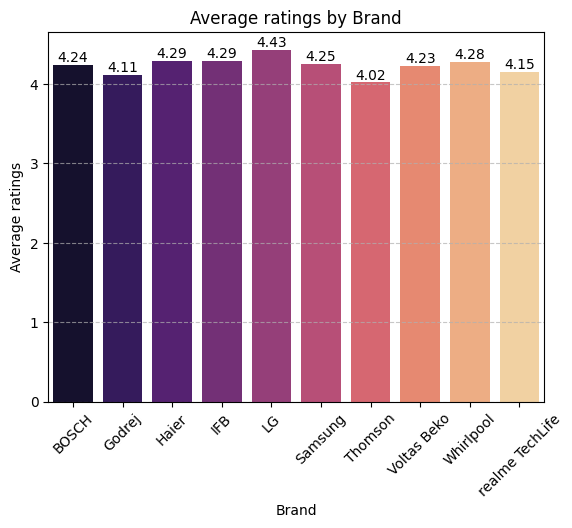

In [1553]:
ax=sns.barplot(data=brand_summary, x='brand', y='avg_rating', palette='magma',)
for x in ax.containers:
  ax.bar_label(x, fontsize=10)
plt.title('Average ratings by Brand')
plt.xlabel('Brand')
plt.ylabel('Average ratings')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [1554]:
brand_summary["reviews_per_sku"] = (
    brand_summary["avg_reviews"] /
    brand_summary["sku_count"]
)

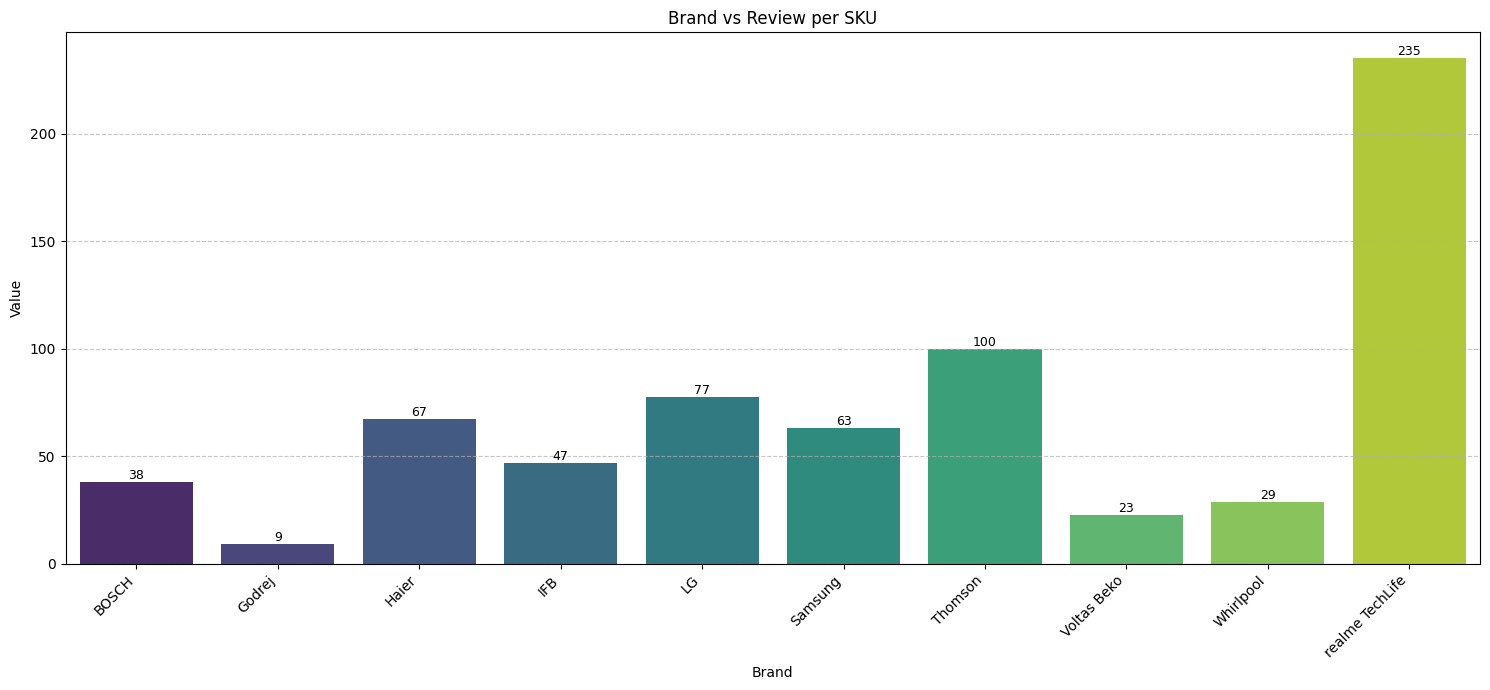

In [1555]:
plt.figure(figsize=(15, 7))
ax = sns.barplot(data=brand_summary, x='brand', y='reviews_per_sku', hue='brand', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=9)

plt.title('Brand vs Review per SKU')
plt.xlabel('Brand')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**Capacity Distribution Analysis**


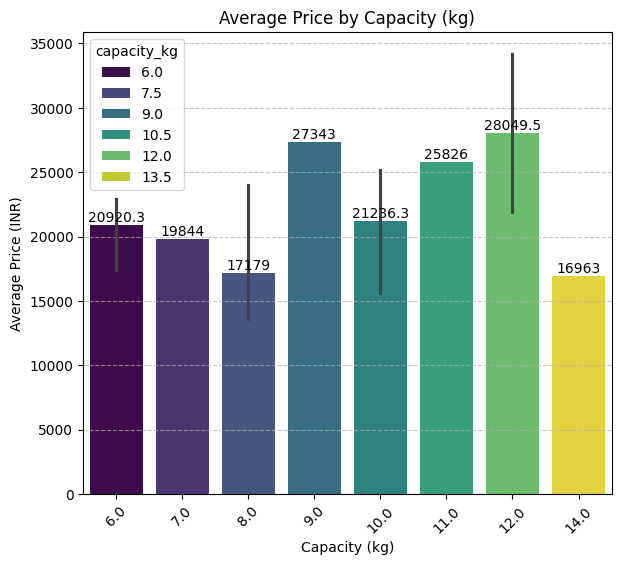

In [1556]:
capacity = df_cleaned.groupby('capacity_kg').agg(
    avg_price=('final_price','mean'), avg_discount=('discount_pct', 'mean'),
    sku_count=('item_id','count')
).reset_index().sort_values(by='capacity_kg').round(0)

capacity=capacity.sort_values(by='capacity_kg')

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
ax=sns.barplot(data=capacity, x='capacity_kg', y='avg_price',hue='capacity_kg' ,palette='viridis')
for x in ax.containers:
  ax.bar_label(x,fontsize=10)
plt.title('Average Price by Capacity (kg)')
plt.xlabel('Capacity (kg)')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)



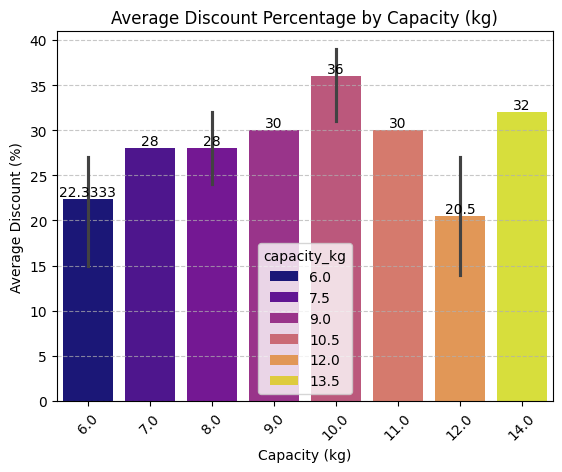

In [1557]:
ax=sns.barplot(data=capacity, x='capacity_kg', y='avg_discount',hue='capacity_kg' , palette='plasma')
for x in ax.containers:
  ax.bar_label(x,fontsize=10)
plt.title('Average Discount Percentage by Capacity (kg)')
plt.xlabel('Capacity (kg)')
plt.ylabel('Average Discount (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


In [1558]:
df_cleaned.columns

Index(['item_id', 'title', 'brand', 'availability', 'availability_date',
       'listing_has_variations', 'return_window', 'star_rating',
       'review_count', 'avg_rating', 'capacity_kg', 'colors',
       'energy_star_ratings', 'automation', 'load_type', 'steam', 'heater',
       'wifi', 'ai', 'inverter', 'category', 'product', 'platform',
       'initial_price', 'final_price', 'discount_pct'],
      dtype='object')

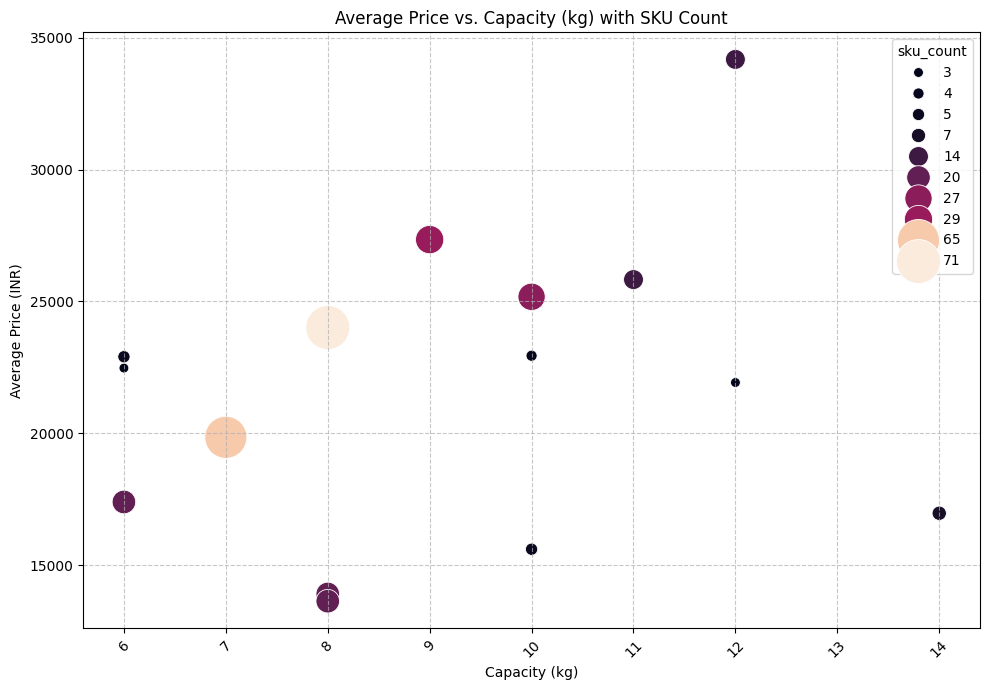

In [1559]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=capacity, x='capacity_kg', y='avg_price', size='sku_count', hue='sku_count', sizes=(50, 1000), legend='full', palette='rocket')
plt.title('Average Price vs. Capacity (kg) with SKU Count')
plt.xlabel('Capacity (kg)')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4938/3870115071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=df_load, x='automation', y='total_items',palette='viridis')


([0, 1], [Text(0, 0, 'Fully Automatic'), Text(1, 0, 'Semi Automatic')])

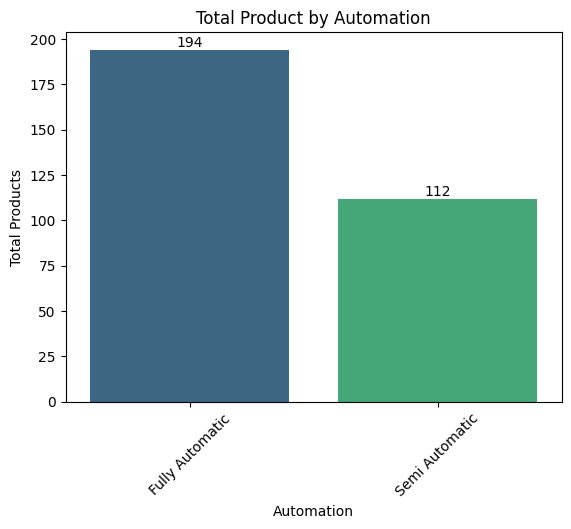

In [1560]:
df_load= df_cleaned.groupby(['automation']).agg(total_items=('item_id','count')).reset_index()

ax=sns.barplot(data=df_load, x='automation', y='total_items',palette='viridis')
for x in ax.containers:
  ax.bar_label(x,fontsize=10)
plt.title('Total Product by Automation')
plt.xlabel('Automation')
plt.ylabel('Total Products')
plt.xticks(rotation=45)




#Feature Analysis

In [1561]:
df_cleaned['total_features_count'] = (
    df_cleaned['ai'].astype(int) +
    df_cleaned['heater'].astype(int) +
    df_cleaned['steam'].astype(int) +
    df_cleaned['wifi'].astype(int) +
    df_cleaned['inverter'].astype(int)
)
df_cleaned['price_per_feature']=df_cleaned['final_price']/df_cleaned['total_features_count']

In [1562]:
df_features=df_cleaned.groupby('total_features_count').agg(avg_price=('final_price','mean'),
                                                   sku_count=('item_id','count'),
                                                   avg_rating=('avg_rating','mean')
                                                   ).reset_index()

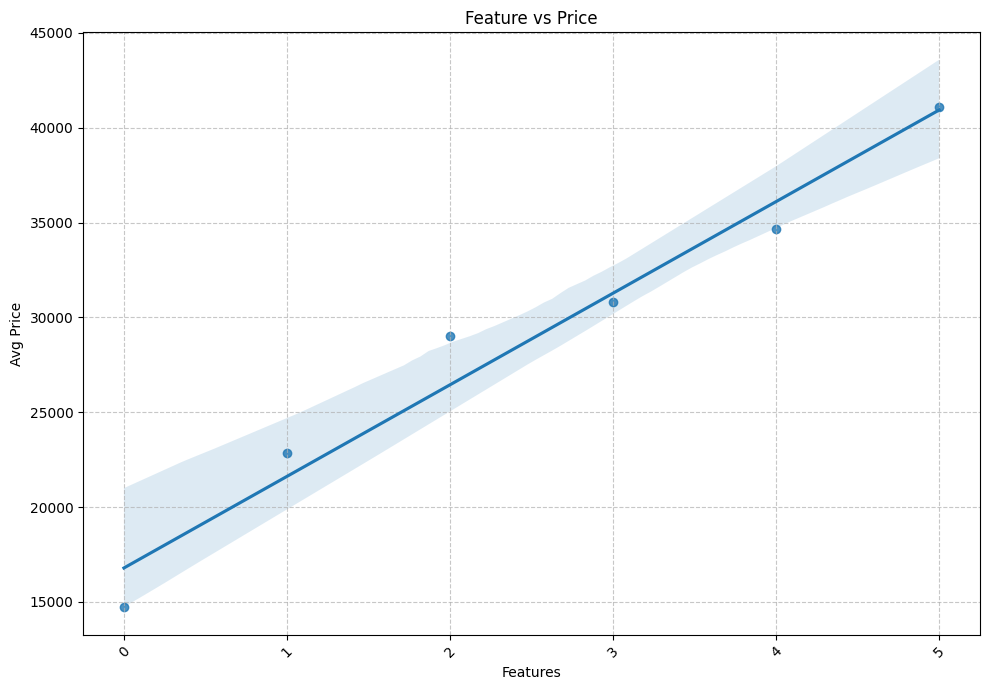

In [1563]:
plt.figure(figsize=(10, 7))
sns.regplot(data=df_features, x='total_features_count', y='avg_price')
plt.title('Feature vs Price')
plt.xlabel('Features')
plt.ylabel('Avg Price')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1564]:
feature_cols = ["ai", "wifi", "steam", "heater", "inverter"]

feature_adoption = (
    df_cleaned[feature_cols]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

feature_adoption.columns = ["Feature", "Adoption_Percentage"]

/tmp/ipykernel_4938/1734238641.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=feature_adoption, x='Feature', y='Adoption_Percentage', palette='plasma')


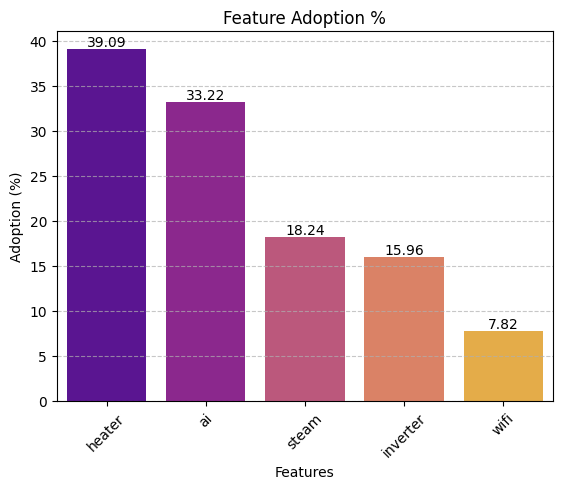

In [1565]:
ax=sns.barplot(data=feature_adoption, x='Feature', y='Adoption_Percentage', palette='plasma')
for x in ax.containers:
  ax.bar_label(x,fontsize=10)
plt.title('Feature Adoption %')
plt.xlabel('Features')
plt.ylabel('Adoption (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


In [1566]:
brand_features = df_cleaned.groupby(['brand']).agg(
    sku_count=('item_id', 'count'),
    avg_price=('final_price', 'mean'),
    avg_rating=('avg_rating', 'mean'),
    avg_reviews=('review_count', 'mean'),
    avg_features=('total_features_count', 'mean')
).reset_index().round(2)

display(brand_features)

,brand,sku_count,avg_price,avg_rating,avg_reviews,avg_features
0,BOSCH,18,31818.06,4.24,688.61,0.89
1,Godrej,31,19379.77,4.11,288.61,0.84
2,Haier,41,20683.27,4.29,2752.46,1.68
3,IFB,39,31314.72,4.29,1828.36,2.59
4,LG,29,28689.48,4.43,2243.34,1.10
5,Samsung,35,24757.57,4.25,2211.66,1.71
6,Thomson,18,11977.50,4.02,1800.00,0.33
7,Voltas Beko,43,16985.88,4.23,981.26,0.33
8,Whirlpool,34,17750.26,4.28,972.59,0.65
9,realme TechLife,19,13200.53,4.15,4474.37,0.26


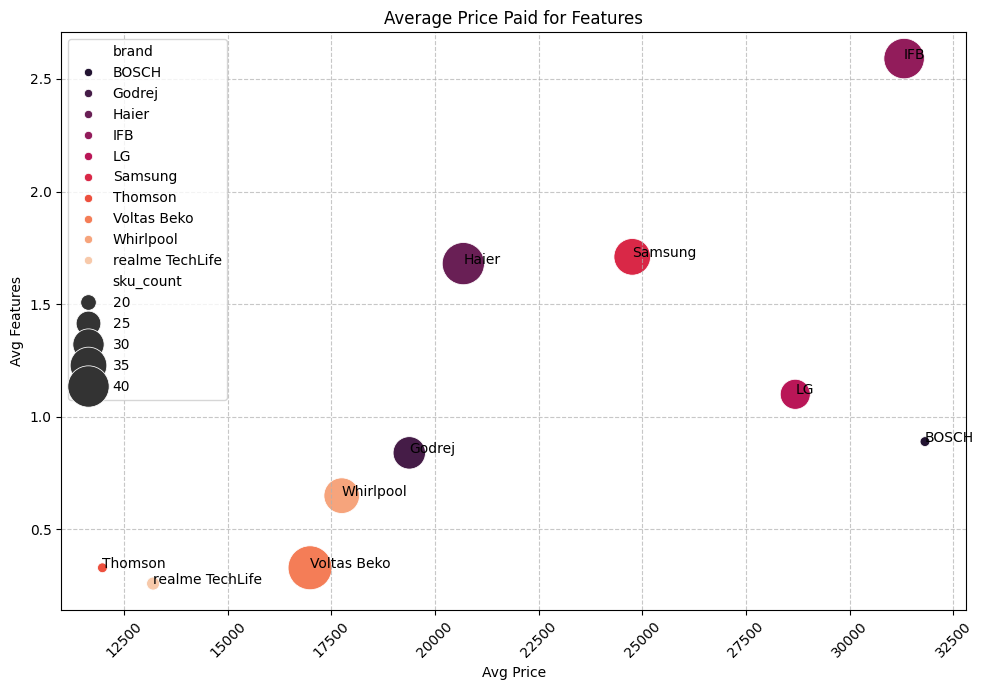

In [1567]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=brand_features, x='avg_price', y='avg_features', size='sku_count', hue='brand',sizes=(50, 1000), palette='rocket')
plt.title('Average Price Paid for Features')
plt.xlabel('Avg Price')
plt.ylabel('Avg Features')
for _, row in brand_features.iterrows():
    plt.annotate(
        row['brand'],
        (row['avg_price'], row['avg_features'])
    )
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()